# EDA Analysis On Dataset `dataset9000.csv` :-

### Import Libraries:-

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os, sys

### goto src folder for ML codes :-

In [2]:
sys.path.append(os.path.abspath('../src'))

### setup styles for matplotlib and seaborn :-

In [3]:
plt.rcParams.update({
    'figure.facecolor':  '#f8f7f4',
    'axes.facecolor':    '#f8f7f4',
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
 
PALETTE = ['#2d5be3','#1d8a5e','#c47c1a','#9b3fbf','#d63031',
           '#0984e3','#6c5ce7','#00b894','#e17055','#fdcb6e',
           '#74b9ff','#a29bfe','#55efc4','#fd79a8','#b2bec3',
           '#dfe6e9','#636e72']
 
print("Libraries loaded successfully!")

Libraries loaded successfully!


### Load datasets :-

In [5]:
DATA_PATH = r'..\data\dataset9000.csv'
 
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()
 
SKILL_COLS = [c for c in df_raw.columns if c != 'Role']


### Check Dataset:-

In [6]:
print(f"Dataset shape   : {df_raw.shape}")
print(f"Skill columns   : {len(SKILL_COLS)}")
print(f"Unique roles    : {df_raw['Role'].nunique()}")
print(f"Missing values  : {df_raw.isnull().sum().sum()}")
print()
print("First 3 rows:")
df_raw.head(3)

Dataset shape   : (9179, 18)
Skill columns   : 17
Unique roles    : 17
Missing values  : 0

First 3 rows:


,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,Professional,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
1,Professional,Poor,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
2,Professional,Beginner,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator


### Encding String values to Integer:-

In [7]:
SKILL_LEVEL_MAP = {
    'Not Interested': 0,
    'Poor':           1,
    'Beginner':       2,
    'Average':        3,
    'Intermediate':   4,
    'Excellent':      5,
    'Professional':   6
}
LEVEL_LABELS = ['Not\nInt.','Poor','Beginner','Average','Inter.','Excel.','Prof.']
 
df = df_raw.copy()
for col in SKILL_COLS:
    df[col] = df[col].map(SKILL_LEVEL_MAP)
 
print("Encoding complete. Sample:")
df.head(3)

Encoding complete. Sample:


,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Database Administrator
1,6,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Database Administrator
2,6,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Database Administrator


### Class Distribution:-

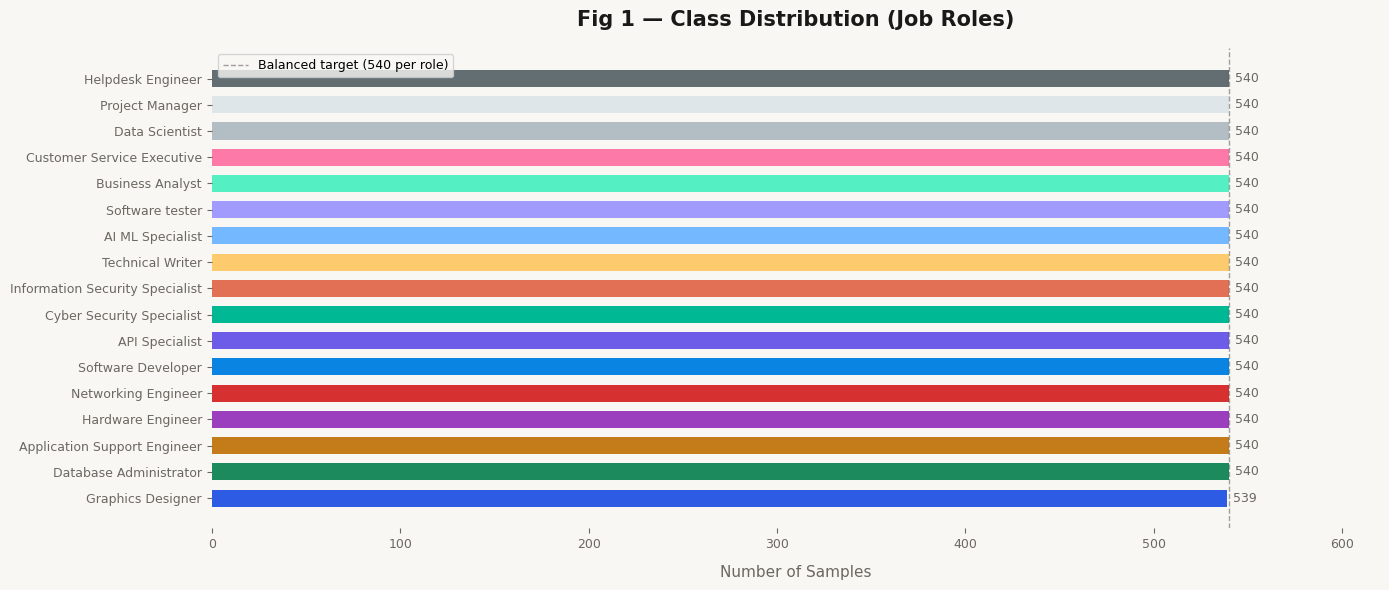

✅ Dataset is perfectly balanced — 540 samples per role


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
 
role_counts = df_raw['Role'].value_counts().sort_values(ascending=True)
bars = ax.barh(role_counts.index, role_counts.values,
               color=PALETTE[:len(role_counts)], edgecolor='none', height=0.65)
 
for bar, val in zip(bars, role_counts.values):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color='#6b6860')
 
ax.set_xlabel('Number of Samples', fontsize=11, color='#6b6860', labelpad=10)
ax.set_title('Fig 1 — Class Distribution (Job Roles)',
             fontsize=15, fontweight='bold', color='#1a1917', pad=16)
ax.tick_params(colors='#6b6860', labelsize=9)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.axvline(540, color='#1a1917', linestyle='--', linewidth=1,
           alpha=0.4, label='Balanced target (540 per role)')
ax.legend(fontsize=9)
ax.set_xlim(0, 620)
 
plt.tight_layout()
plt.savefig('Quiz_dataset_eda/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset is perfectly balanced — 540 samples per role")
 

### Skill Level Distributions:-

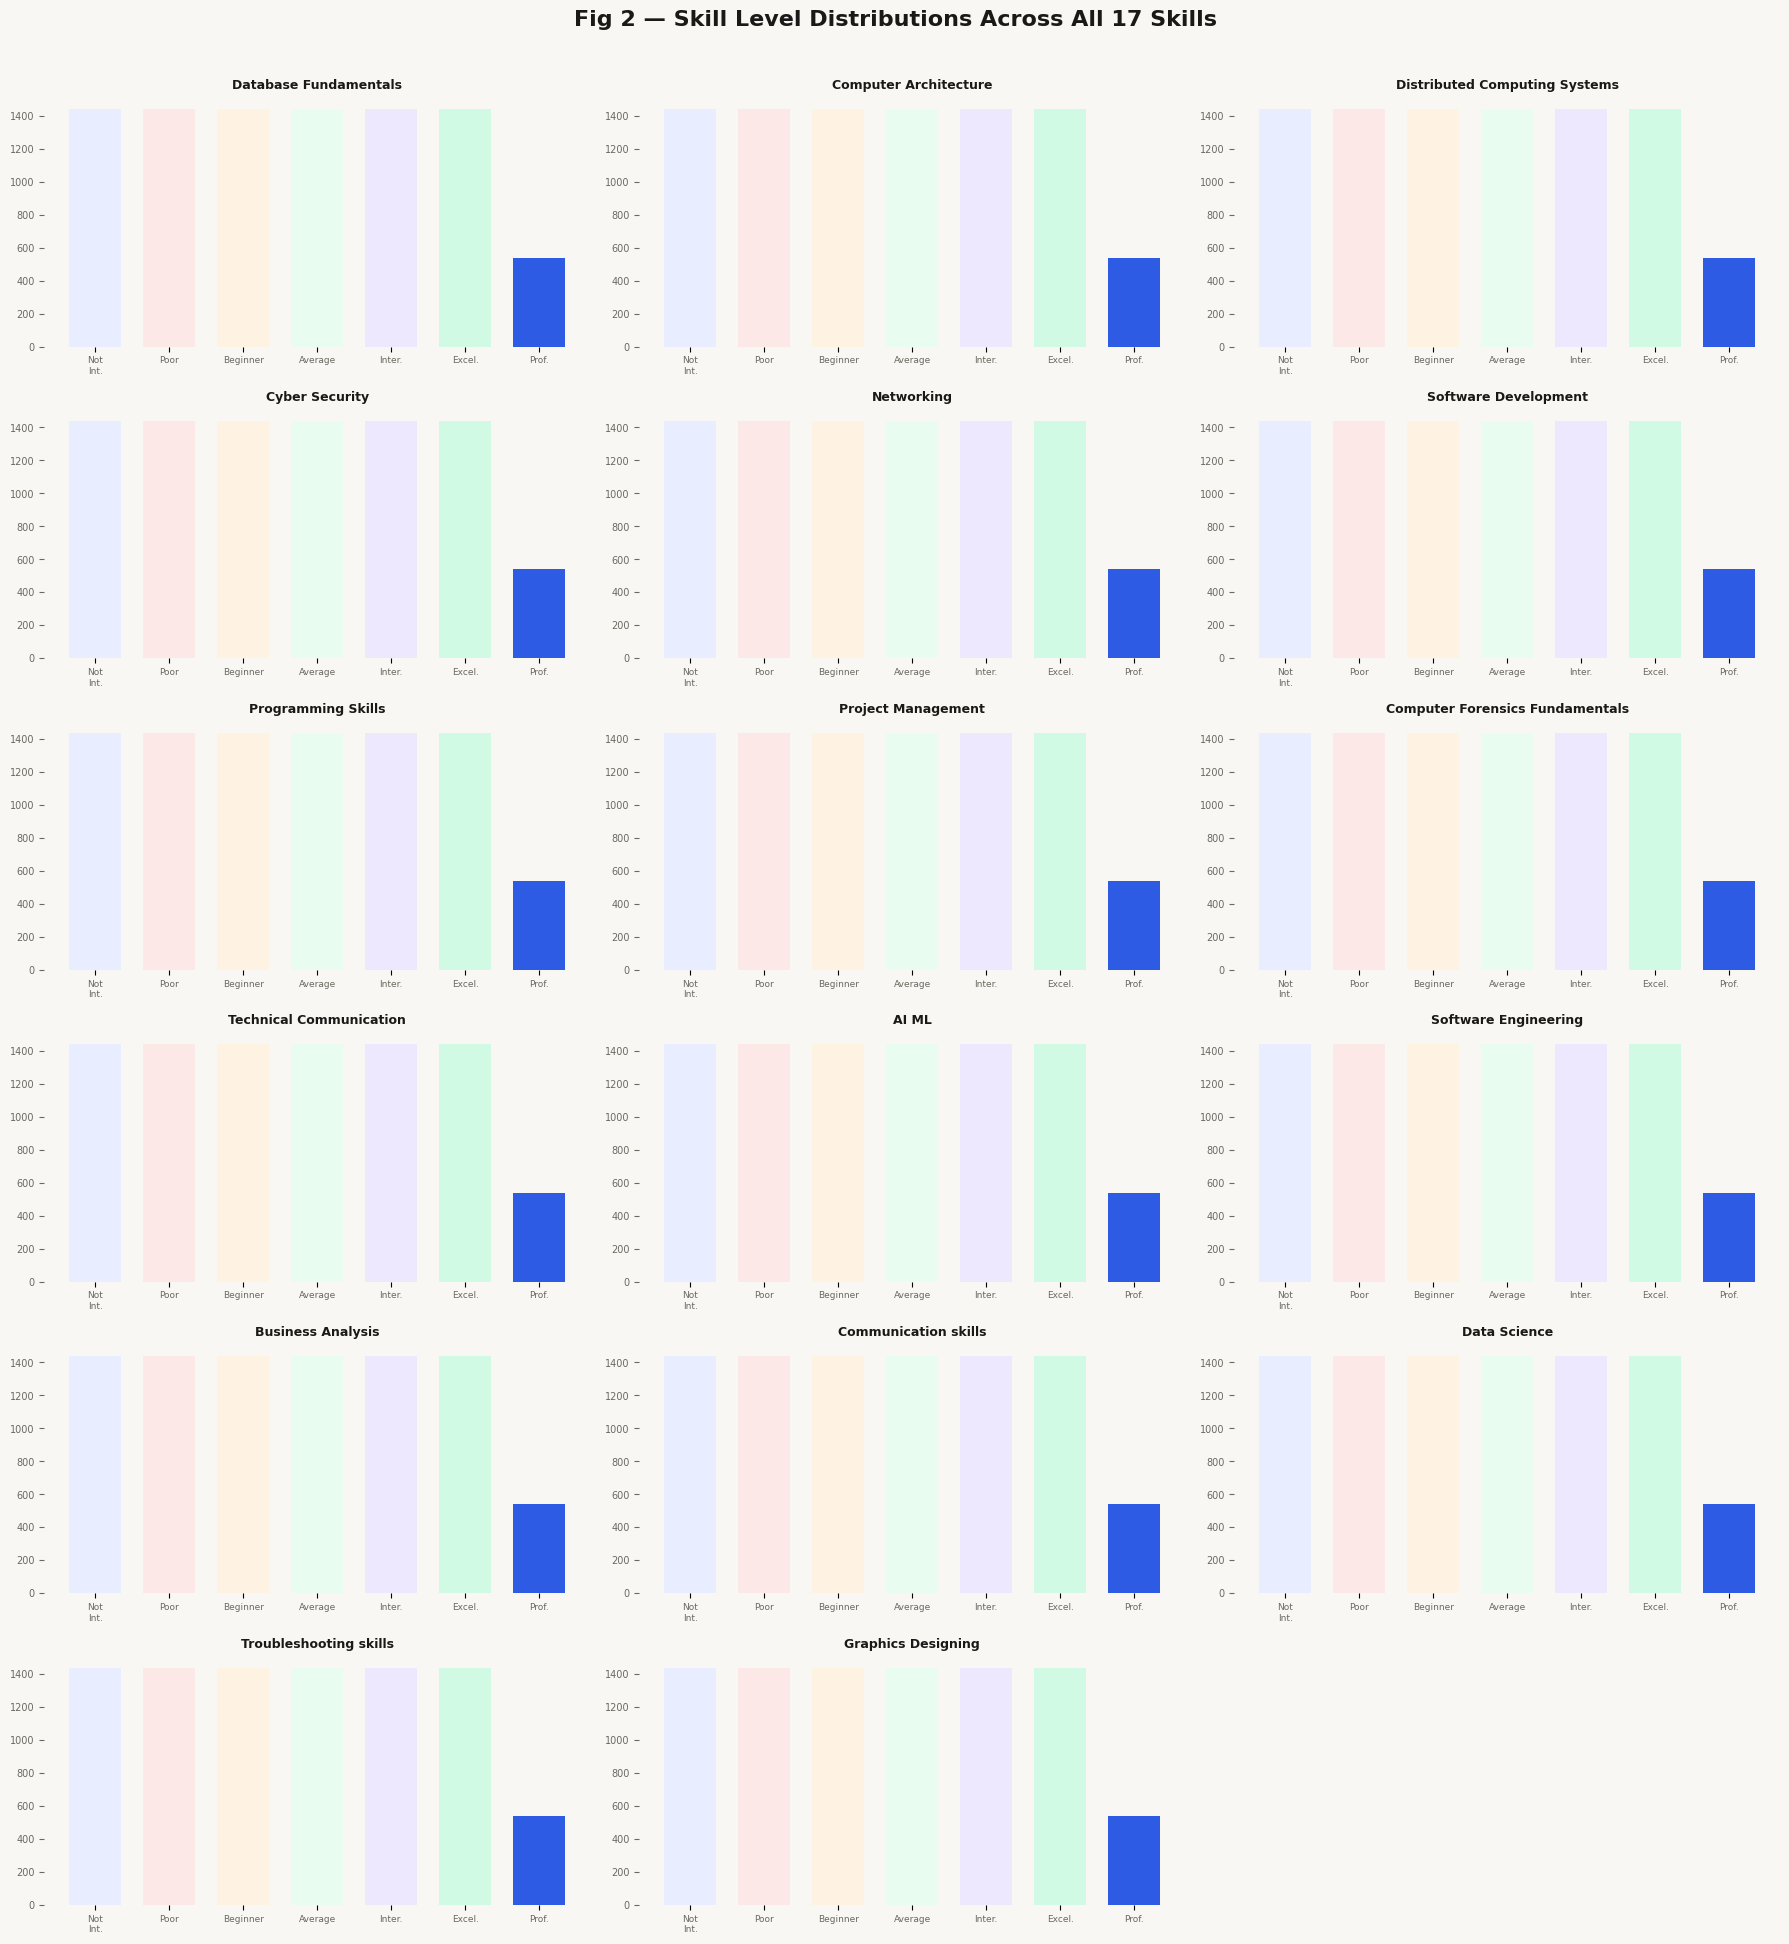

✅ All skill levels are uniformly distributed — no bias in feature values


In [10]:
n_skills = len(SKILL_COLS)   # 17
ncols    = 3
nrows    = (n_skills + ncols - 1) // ncols   # 6
 
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
fig.suptitle('Fig 2 — Skill Level Distributions Across All 17 Skills',
             fontsize=16, fontweight='bold', color='#1a1917', y=1.01)
axes = axes.flatten()
 
bar_colors = ['#e8eeff','#fde8e8','#fef3e2','#e8fdf0',
              '#ede8fe','#d1fae5','#2d5be3']
 
for i, col in enumerate(SKILL_COLS):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values,
           color=[bar_colors[int(x)] for x in counts.index],
           edgecolor='none', width=0.7)
    ax.set_title(col, fontsize=9, fontweight='600', color='#1a1917', pad=6)
    ax.set_xticks(range(7))
    ax.set_xticklabels(LEVEL_LABELS, fontsize=6.5, color='#6b6860')
    ax.tick_params(axis='y', labelsize=7, colors='#6b6860')
    ax.spines[['top','right','left','bottom']].set_visible(False)
 
for j in range(n_skills, len(axes)):
    axes[j].set_visible(False)
 
plt.tight_layout()
plt.savefig('Quiz_dataset_eda/fig2_skill_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All skill levels are uniformly distributed — no bias in feature values")

### Correlation Heatmap:-

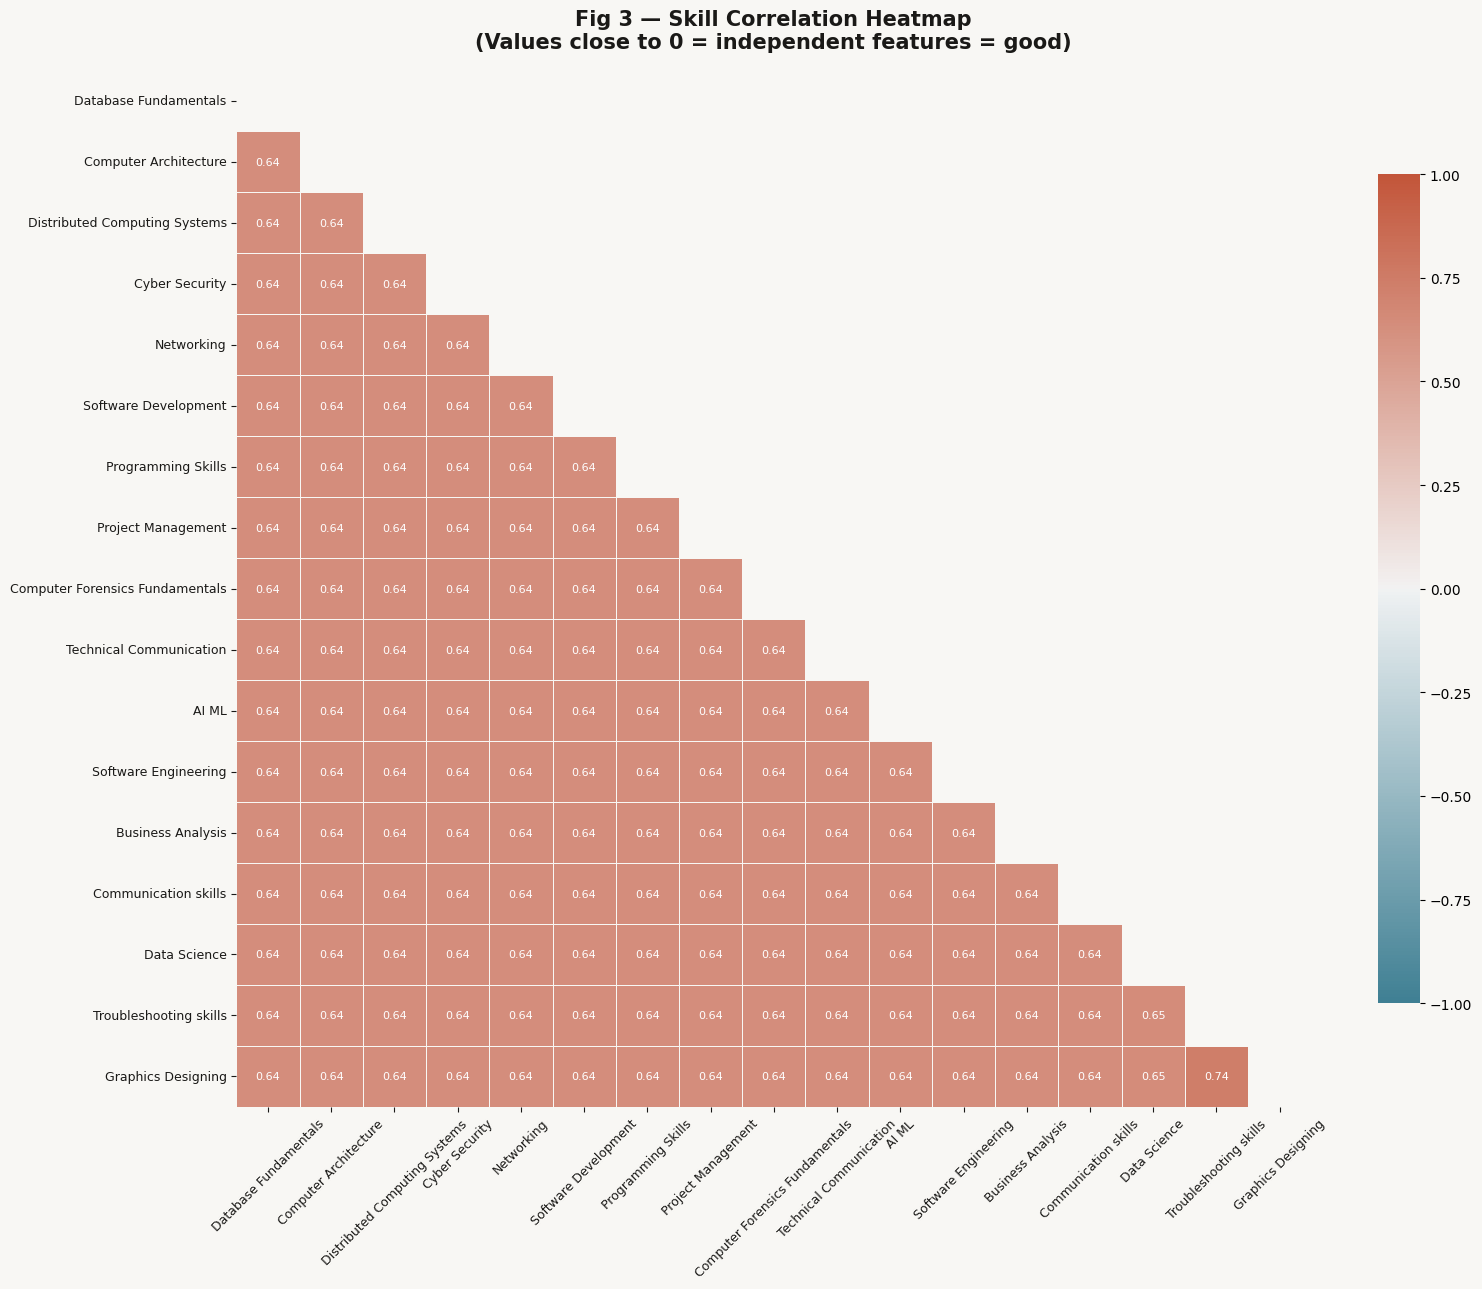

⚠️  Pairs with correlation > 0.3:
   Computer Architecture ↔ Database Fundamentals : 0.639
   Distributed Computing Systems ↔ Database Fundamentals : 0.639
   Distributed Computing Systems ↔ Computer Architecture : 0.639
   Cyber Security ↔ Database Fundamentals : 0.639
   Cyber Security ↔ Computer Architecture : 0.639
   Cyber Security ↔ Distributed Computing Systems : 0.639
   Networking ↔ Database Fundamentals : 0.639
   Networking ↔ Computer Architecture : 0.639
   Networking ↔ Distributed Computing Systems : 0.639
   Networking ↔ Cyber Security : 0.639
   Software Development ↔ Database Fundamentals : 0.639
   Software Development ↔ Computer Architecture : 0.639
   Software Development ↔ Distributed Computing Systems : 0.639
   Software Development ↔ Cyber Security : 0.639
   Software Development ↔ Networking : 0.639
   Programming Skills ↔ Database Fundamentals : 0.639
   Programming Skills ↔ Computer Architecture : 0.639
   Programming Skills ↔ Distributed Computing Systems : 0.

In [11]:
fig, ax = plt.subplots(figsize=(16, 13))
 
corr = df[SKILL_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
cmap = sns.diverging_palette(220, 20, as_cmap=True)
 
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#f8f7f4',
            annot_kws={'size': 8}, ax=ax,
            cbar_kws={'shrink': 0.8})
 
ax.set_title('Fig 3 — Skill Correlation Heatmap\n(Values close to 0 = independent features = good)',
             fontsize=15, fontweight='bold', color='#1a1917', pad=16)
ax.tick_params(axis='x', rotation=45, labelsize=9, colors='#1a1917')
ax.tick_params(axis='y', rotation=0,  labelsize=9, colors='#1a1917')
 
plt.tight_layout()
plt.savefig('Quiz_dataset_eda/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print correlation insight
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.3:
            high_corr.append((corr.columns[i], corr.columns[j], round(val, 3)))
 
if high_corr:
    print("⚠️  Pairs with correlation > 0.3:")
    for a, b, v in high_corr:
        print(f"   {a} ↔ {b} : {v}")
else:
    print("✅ No highly correlated feature pairs — features are independent (ideal for ML)")

### Mean Skill per Role Heatmap:-

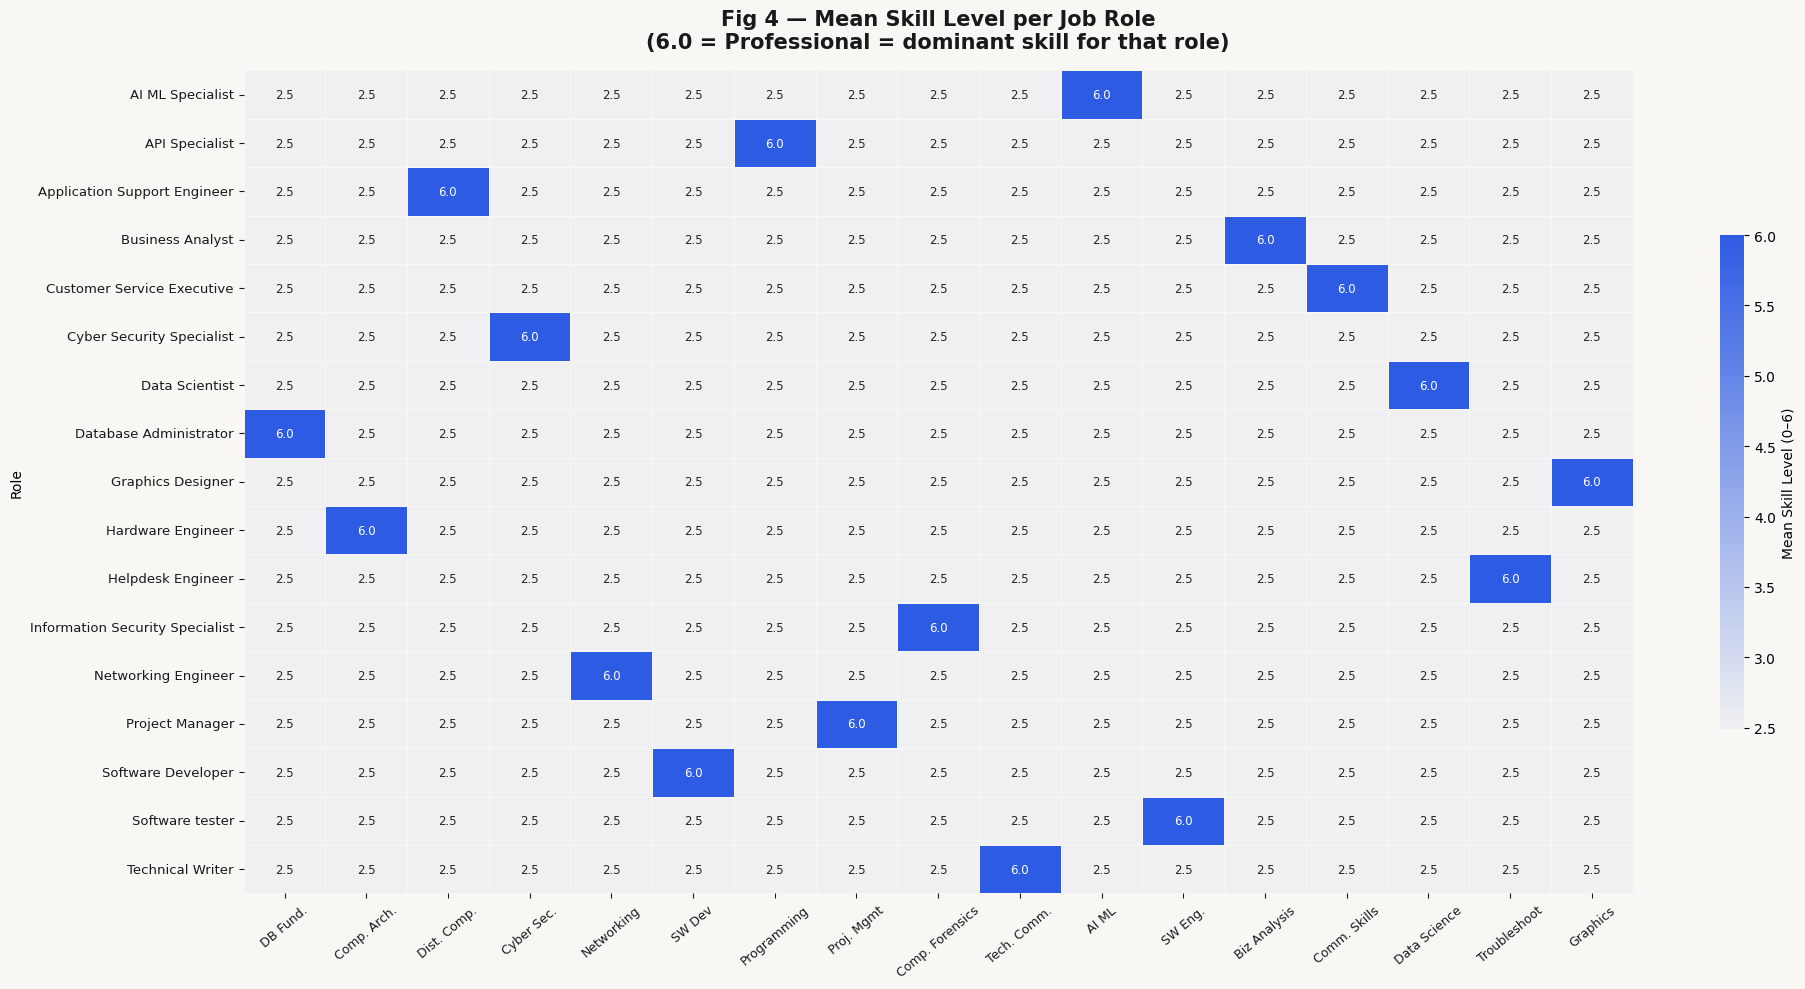

✅ Each role has exactly ONE dominant skill at level 6.0 — clean, separable classes


In [12]:
short_names = ['DB Fund.','Comp. Arch.','Dist. Comp.','Cyber Sec.',
               'Networking','SW Dev','Programming','Proj. Mgmt',
               'Comp. Forensics','Tech. Comm.','AI ML','SW Eng.',
               'Biz Analysis','Comm. Skills','Data Science',
               'Troubleshoot','Graphics']
 
role_means = df.groupby('Role')[SKILL_COLS].mean().copy()
role_means.columns = short_names
 
fig, ax = plt.subplots(figsize=(20, 10))
cmap2 = sns.light_palette('#2d5be3', as_cmap=True)
 
sns.heatmap(role_means, annot=True, fmt='.1f', cmap=cmap2,
            linewidths=0.5, linecolor='#f8f7f4',
            annot_kws={'size': 8.5}, ax=ax,
            cbar_kws={'shrink': 0.6, 'label': 'Mean Skill Level (0–6)'})
 
ax.set_title('Fig 4 — Mean Skill Level per Job Role\n'
             '(6.0 = Professional = dominant skill for that role)',
             fontsize=15, fontweight='bold', color='#1a1917', pad=16)
ax.tick_params(axis='x', rotation=40, labelsize=9,  colors='#1a1917')
ax.tick_params(axis='y', rotation=0,  labelsize=9.5, colors='#1a1917')
 
plt.tight_layout()
plt.savefig('Quiz_dataset_eda/fig4_role_skill_means.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Each role has exactly ONE dominant skill at level 6.0 — clean, separable classes")

### Dominant Skill per Role:-

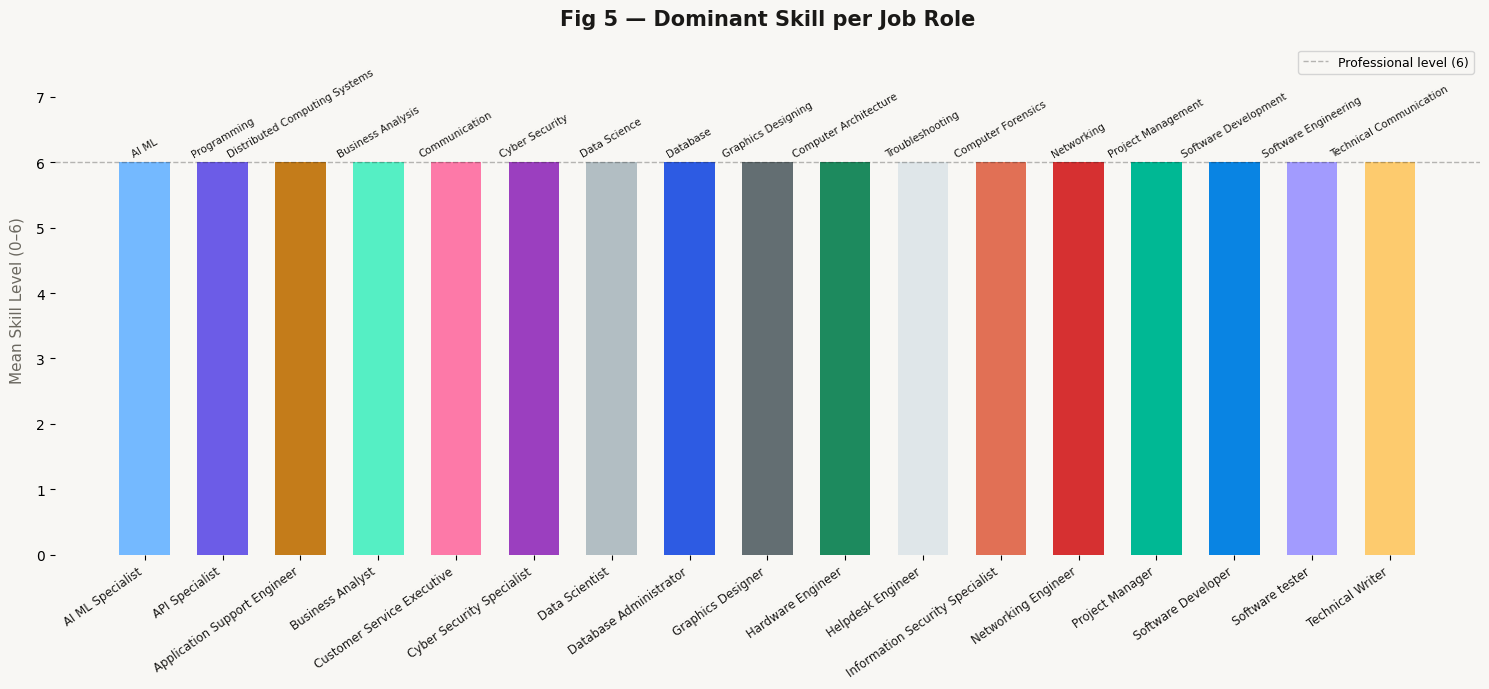


Dominant skill → Role mapping:
  AI ML Specialist                       ← AI ML
  API Specialist                         ← Programming Skills
  Application Support Engineer           ← Distributed Computing Systems
  Business Analyst                       ← Business Analysis
  Customer Service Executive             ← Communication skills
  Cyber Security Specialist              ← Cyber Security
  Data Scientist                         ← Data Science
  Database Administrator                 ← Database Fundamentals
  Graphics Designer                      ← Graphics Designing
  Hardware Engineer                      ← Computer Architecture
  Helpdesk Engineer                      ← Troubleshooting skills
  Information Security Specialist        ← Computer Forensics Fundamentals
  Networking Engineer                    ← Networking
  Project Manager                        ← Project Management
  Software Developer                     ← Software Development
  Software tester               

In [13]:
role_means_orig = df.groupby('Role')[SKILL_COLS].mean()
dominant_skill  = role_means_orig.idxmax(axis=1)
dominant_val    = role_means_orig.max(axis=1).sort_values(ascending=False)
 
fig, ax = plt.subplots(figsize=(15, 7))
 
roles        = dominant_val.index
vals         = dominant_val.values
skills       = [dominant_skill[r] for r in roles]
colors_used  = [PALETTE[SKILL_COLS.index(s) % len(PALETTE)] for s in skills]
 
bars = ax.bar(range(len(roles)), vals, color=colors_used, edgecolor='none', width=0.65)
 
for bar, skill in zip(bars, skills):
    short = skill.replace(' Fundamentals','').replace(' Skills','').replace(' skills','')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            short, ha='center', va='bottom', fontsize=7.5,
            color='#1a1917', fontweight='500', rotation=30)
 
ax.set_xticks(range(len(roles)))
ax.set_xticklabels(roles, rotation=35, ha='right', fontsize=8.5, color='#1a1917')
ax.set_ylabel('Mean Skill Level (0–6)', fontsize=11, color='#6b6860', labelpad=8)
ax.set_title('Fig 5 — Dominant Skill per Job Role',
             fontsize=15, fontweight='bold', color='#1a1917', pad=14)
ax.set_ylim(0, 7.8)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.axhline(6, color='#1a1917', linestyle='--', linewidth=1,
           alpha=0.3, label='Professional level (6)')
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('Quiz_dataset_eda/fig5_dominant_skill.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\nDominant skill → Role mapping:")
for role, skill in dominant_skill.items():
    print(f"  {role:<38} ← {skill}")
 

### Summary:-

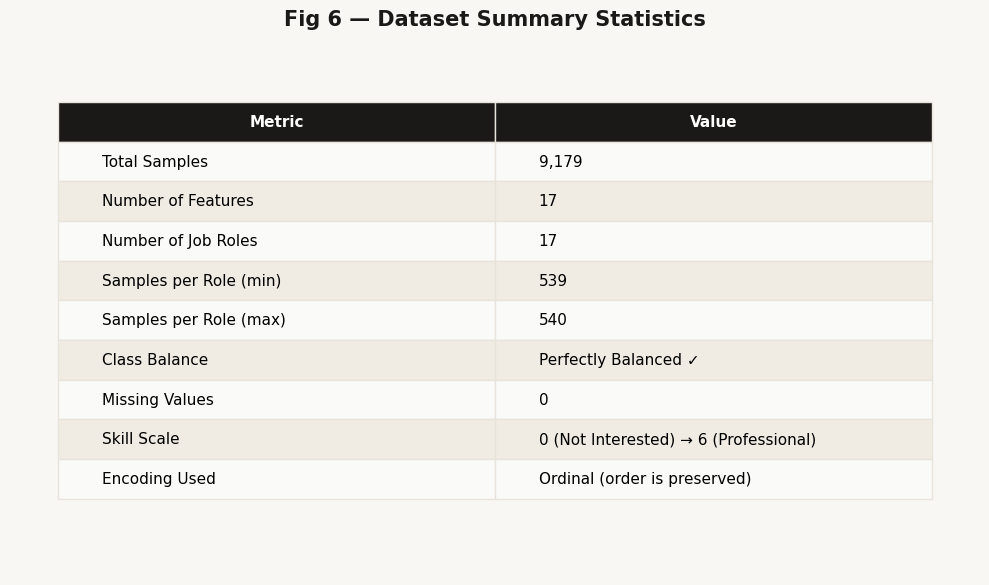

✅ Dataset analysis complete — all 6 figures generated and saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
 
stats_data = [
    ['Total Samples',          f"{len(df):,}"],
    ['Number of Features',     f"{len(SKILL_COLS)}"],
    ['Number of Job Roles',    f"{df_raw['Role'].nunique()}"],
    ['Samples per Role (min)', f"{df_raw['Role'].value_counts().min()}"],
    ['Samples per Role (max)', f"{df_raw['Role'].value_counts().max()}"],
    ['Class Balance',          'Perfectly Balanced ✓'],
    ['Missing Values',         f"{df.isnull().sum().sum()}"],
    ['Skill Scale',            '0 (Not Interested) → 6 (Professional)'],
    ['Encoding Used',          'Ordinal (order is preserved)'],
]
 
table = ax.table(cellText=stats_data,
                 colLabels=['Metric', 'Value'],
                 cellLoc='left', loc='center',
                 colWidths=[0.45, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)
 
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#e8e4dc')
    if row == 0:
        cell.set_facecolor('#1a1917')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0ece4')
    else:
        cell.set_facecolor('#fafaf8')
 
ax.set_title('Fig 6 — Dataset Summary Statistics',
             fontsize=15, fontweight='bold', color='#1a1917', pad=20, y=0.95)
plt.tight_layout()
plt.savefig('Quiz_dataset_eda/fig6_summary_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset analysis complete — all 6 figures generated and saved")
